# 04 - Error Analysis

Detaillierte Fehleranalyse des besten Modells (GBERT).

**Inhalte:**
- False Positives & False Negatives inspizieren
- Fehlermuster identifizieren
- Fehlerverteilung nach Textlänge
- Statistische Signifikanztests
- Qualitative Beispiele für die Hausarbeit

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import confusion_matrix, classification_report

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

from src.config import MODELS, MODELS_DIR, LABEL_NAMES, MAX_LENGTH, SEED, PLOTS_DIR
from src.data_loader import load_data, create_hf_dataset
from src.utils import set_seed

set_seed(SEED)
sns.set_style('whitegrid')
print('Setup complete!')

s:\Monolinguales Hate Speech Classification\.conda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🎲 Random Seed gesetzt: 42
Setup complete!


## 1. Modell laden & Vorhersagen generieren

In [2]:
# Bestes Modell laden (GBERT, bester Fold)
model_path = str(MODELS_DIR / 'gbert_best' / 'fold_0')

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)
print(f'Modell geladen auf {device}')

W0314 20:45:28.647000 6560 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Modell geladen auf cuda


In [3]:
# Testdaten laden & Vorhersagen
_, test_df = load_data(preprocessing_variant='full_preprocessing')

predictions = []
probabilities = []

model.eval()
with torch.no_grad():
    for i in range(0, len(test_df), 32):
        batch_texts = test_df['text'].iloc[i:i+32].tolist()
        inputs = tokenizer(batch_texts, padding=True, truncation=True,
                          max_length=MAX_LENGTH, return_tensors='pt').to(device)
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        preds = torch.argmax(probs, dim=-1)
        predictions.extend(preds.cpu().numpy())
        probabilities.extend(probs.cpu().numpy())

test_df['prediction'] = predictions
test_df['prob_other'] = [p[0] for p in probabilities]
test_df['prob_offense'] = [p[1] for p in probabilities]
test_df['correct'] = test_df['label'] == test_df['prediction']

accuracy = test_df['correct'].mean()
print(f'Test Accuracy: {accuracy:.4f}')
print(f'Fehler: {(~test_df["correct"]).sum()} von {len(test_df)}')

Test Accuracy: 0.7906
Fehler: 715 von 3414


## 2. Confusion Matrix

In [4]:
y_true = test_df['label'].values
y_pred = test_df['prediction'].values

# Classification Report
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES))

# Confusion Matrix Visualisierung ausgelagert in: scripts/generate_all_plots.py
# Siehe: results/plots/confusion_matrices/cm_gbert.png

print('\n✅ Confusion Matrix Plots werden durch scripts/generate_all_plots.py erstellt.')


              precision    recall  f1-score   support

       OTHER       0.78      0.94      0.86      2244
     OFFENSE       0.82      0.50      0.62      1170

    accuracy                           0.79      3414
   macro avg       0.80      0.72      0.74      3414
weighted avg       0.80      0.79      0.77      3414


✅ Confusion Matrix Plots werden durch scripts/generate_all_plots.py erstellt.


## 3. False Positives analysieren

In [5]:
# False Positives: Modell sagt OFFENSE, aber tatsächlich OTHER
fp = test_df[(test_df['label'] == 0) & (test_df['prediction'] == 1)].copy()
fp = fp.sort_values('prob_offense', ascending=False)

print(f'False Positives: {len(fp)}')
print(f'\nTop 20 False Positives (höchste Confidence):')
print('=' * 80)
for i, (_, row) in enumerate(fp.head(20).iterrows()):
    print(f'[{i+1}] P(OFF)={row["prob_offense"]:.3f} | {row["text"][:100]}')
    print()

False Positives: 125

Top 20 False Positives (höchste Confidence):
[1] P(OFF)=0.972 | @USER Es macht mich sowas von Wütend! Wie Krank ist diese Mutter. Wie Krank diese widerlichen Typen!

[2] P(OFF)=0.970 | @USER |LBR| Denuzianten sind immer Lumpen. Egal von welcher Seite.

[3] P(OFF)=0.967 | @USER |LBR| Genau diese feigen Fahnenflüchtlinge gehören an die Front in Syrien!

[4] P(OFF)=0.953 | @USER @USER |LBR| Bin Armutsrentner und habeauch kein Freies WLAN sondern zahle für eine Flatrate mo

[5] P(OFF)=0.949 | @USER du hast mich falsch verstanden , wir sind die kleinen deppen und müssen für die Elite arbeiten

[6] P(OFF)=0.941 | Lacht die Sozis und inre Merkeltruppe aus!Macht die Knechte lächerlich!

[7] P(OFF)=0.939 | Merkel und ihre Vasallen müssen weg!

[8] P(OFF)=0.938 | @USER ,so ein Unfähiger Politiker wie sie es sind ,gab es schon lange nicht mehr ! TTipp darf es nic

[9] P(OFF)=0.936 | @USER Die Kommunen jammern, die Länder jammern! Will heißen, man bereitet die doofe Melkkuh -

## 4. False Negatives analysieren

In [6]:
# False Negatives: Modell sagt OTHER, aber tatsächlich OFFENSE
fn = test_df[(test_df['label'] == 1) & (test_df['prediction'] == 0)].copy()
fn = fn.sort_values('prob_other', ascending=False)

print(f'False Negatives: {len(fn)}')
print(f'\nTop 20 False Negatives (höchste Confidence):')
print('=' * 80)
for i, (_, row) in enumerate(fn.head(20).iterrows()):
    print(f'[{i+1}] P(OTHER)={row["prob_other"]:.3f} | {row["text"][:100]}')
    print()

False Negatives: 590

Top 20 False Negatives (höchste Confidence):
[1] P(OTHER)=0.991 | @USER @USER @USER @USER @USER @USER @USER Ich respektiere Deinen Glauben nicht.

[2] P(OTHER)=0.990 | @USER @USER @USER Wie gesagt: "Nein" heißt nicht in jedem fall "Nein". Es kann auch heißen: "Lass mi

[3] P(OTHER)=0.990 | @USER @USER @USER @USER @USER @USER @USER Und das sagt alles über Dich aus, was es wert ist, zu wiss

[4] P(OTHER)=0.988 | @USER @USER @USER @USER @USER @USER @USER Noch einmal: Ich bin Atheist. Ich bin liberal. Ich lehne d

[5] P(OTHER)=0.988 | @USER @USER @USER @USER Vielleicht einfach mal mehr Journalismus machen und weniger Propaganda.

[6] P(OTHER)=0.988 | Haben sich @USER schon zu den antisemitischen Demonstrationen ihrer Lieblingsreligion geäußert?

[7] P(OTHER)=0.987 | @USER @USER @USER Der Staatsfunk hat halt einen politischen Auftrag.

[8] P(OTHER)=0.987 | @USER @USER @USER Ich weiß worum es geht: Um Frauen und ihre emotionalen Befindlichkeiten. Wie immer

[9] P(OTHER)

## 5. Fehlerverteilung nach Textlänge

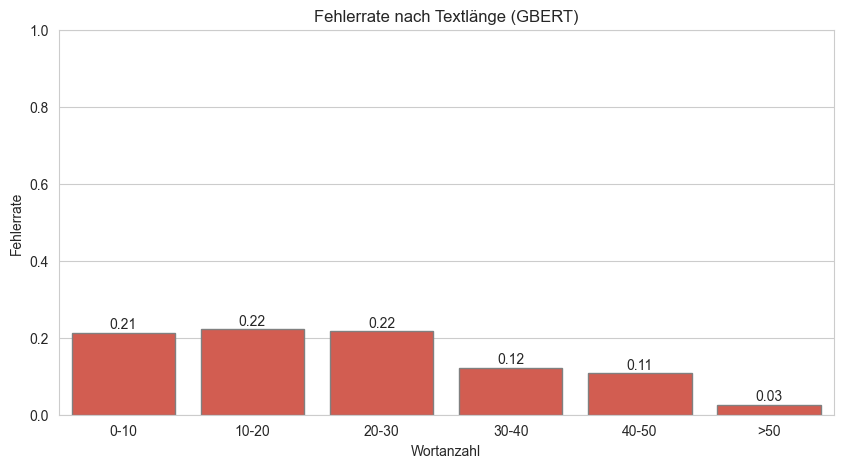

Korrelation Wortanzahl <-> Korrektheit: 0.0665


In [7]:
# Implementierung der Fehlerverteilung
def plot_error_distribution_local(y_true, y_pred, texts, model_name):
    # Calculate lengths
    lengths = [len(str(t).split()) for t in texts]
    correct = y_true == y_pred
    
    df = pd.DataFrame({'length': lengths, 'correct': correct})
    # Binning
    bins = [0, 10, 20, 30, 40, 50, 100]
    labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '>50']
    df['bin'] = pd.cut(df['length'], bins=bins, labels=labels)
    
    # Error rate per bin
    # Error rate = 1 - Accuracy (mean of correct)
    error_rates = 1 - df.groupby('bin', observed=False)['correct'].mean()
    
    # Plot
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(x=error_rates.index, y=error_rates.values, color='#e74c3c', edgecolor='gray')
    plt.title(f'Fehlerrate nach Textlänge ({model_name})')
    plt.ylabel('Fehlerrate')
    plt.xlabel('Wortanzahl')
    
    # Add values
    for i, v in enumerate(error_rates.values):
        if not np.isnan(v):
            ax.text(i, v + 0.01, f'{v:.2f}', ha='center')
            
    plt.ylim(0, 1.0)
    plt.show()

plot_error_distribution_local(
    y_true, y_pred,
    test_df['text'].tolist(),
    'GBERT'
)

# Korrelation Textlänge <-> Korrektheit
test_df['word_count'] = test_df['text'].str.split().str.len()
corr = test_df['word_count'].corr(test_df['correct'].astype(float))
print(f'Korrelation Wortanzahl <-> Korrektheit: {corr:.4f}')

## 6. Statistische Signifikanztests

In [8]:
# CV-Ergebnisse laden (falls vorhanden)
import json
from pathlib import Path

metrics_dir = Path('../results/metrics')

try:
    with open(metrics_dir / 'GBERT_cv_results.json') as f:
        gbert_results = json.load(f)
    with open(metrics_dir / 'mBERT_cv_results.json') as f:
        mbert_results = json.load(f)
    with open(metrics_dir / 'HateBERT_cv_results.json') as f:
        hatebert_results = json.load(f)
    
    gbert_f1 = gbert_results['f1_macro_values']
    mbert_f1 = mbert_results['f1_macro_values']
    hatebert_f1 = hatebert_results['f1_macro_values']
    
    print('Paired t-tests (5-Fold CV F1-Scores):')
    print('=' * 50)
    
    # GBERT vs mBERT
    t1, p1 = stats.ttest_rel(gbert_f1, mbert_f1)
    print(f'GBERT vs mBERT:    t={t1:.4f}, p={p1:.4f} {"*" if p1 < 0.05 else "(n.s.)"}')
    
    # GBERT vs HateBERT
    t2, p2 = stats.ttest_rel(gbert_f1, hatebert_f1)
    print(f'GBERT vs HateBERT: t={t2:.4f}, p={p2:.4f} {"*" if p2 < 0.05 else "(n.s.)"}')
    
    # mBERT vs HateBERT
    t3, p3 = stats.ttest_rel(mbert_f1, hatebert_f1)
    print(f'mBERT vs HateBERT: t={t3:.4f}, p={p3:.4f} {"*" if p3 < 0.05 else "(n.s.)"}')
    
except FileNotFoundError:
    print('CV-Ergebnisse noch nicht vorhanden.')
    print('Bitte zuerst Experiment 2 (experiments/02_bert_full_data.py) ausführen.')

Paired t-tests (5-Fold CV F1-Scores):
GBERT vs mBERT:    t=2.8180, p=0.0479 *
GBERT vs HateBERT: t=20.3802, p=0.0000 *
mBERT vs HateBERT: t=17.4215, p=0.0001 *


## 7. Qualitative Fehleranalyse - Muster

### Typische Fehlermuster:

1. **Ironie/Sarkasmus**: Modell erkennt offensive Sprache nicht bei ironischem Gebrauch
2. **Implizite Hate Speech**: Beleidigungen ohne explizite Schimpfwörter
3. **Zitierende Tweets**: Tweets, die offensive Sprache zitieren, um sie zu kritisieren
4. **Kontext-Abhängigkeit**: Wörter, die je nach Kontext beleidigend oder neutral sind

In [9]:
# Beispiele für die Hausarbeit extrahieren
print('Beispiele für die Hausarbeit:')
print('=' * 80)

# Korrekte Klassifikationen (je 3 pro Klasse)
print('\n--- Korrekte Klassifikationen ---')
correct_other = test_df[(test_df['correct']) & (test_df['label'] == 0)].head(3)
correct_offense = test_df[(test_df['correct']) & (test_df['label'] == 1)].head(3)

for _, row in correct_other.iterrows():
    print(f'  [OTHER✓] {row["text"][:80]}')
for _, row in correct_offense.iterrows():
    print(f'  [OFFENSE✓] {row["text"][:80]}')

# False Positives (3 Beispiele)
print('\n--- False Positives (Modell: OFFENSE, Wahrheit: OTHER) ---')
for _, row in fp.head(3).iterrows():
    print(f'  [FP] P(OFF)={row["prob_offense"]:.3f} | {row["text"][:80]}')

# False Negatives (3 Beispiele)
print('\n--- False Negatives (Modell: OTHER, Wahrheit: OFFENSE) ---')
for _, row in fn.head(3).iterrows():
    print(f'  [FN] P(OTHER)={row["prob_other"]:.3f} | {row["text"][:80]}')

Beispiele für die Hausarbeit:

--- Korrekte Klassifikationen ---
  [OTHER✓] Meine Mutter hat mir erzählt, dass mein Vater einen Wahlkreiskandidaten nicht ge
  [OTHER✓] @USER @USER Meine Reaktion; |LBR| Nicht jeder Moslem ist ein Terrorist. Aber jed
  [OTHER✓] @USER Die Bibel enthält ebenfalls Gesetze des Zivil- und Strafrechts.
  [OFFENSE✓] @USER Besser einen schwarz arbeiten zu lassen als PÄDOPHILE Bastarde in der Part
  [OFFENSE✓] @USER @USER @USER Von mir aus könnt ihr jämmerlich verrecken
  [OFFENSE✓] @USER @USER Zum Mond? Da sind doch auf der Kehrseite schon die Reichsdeutschen m

--- False Positives (Modell: OFFENSE, Wahrheit: OTHER) ---
  [FP] P(OFF)=0.972 | @USER Es macht mich sowas von Wütend! Wie Krank ist diese Mutter. Wie Krank dies
  [FP] P(OFF)=0.970 | @USER |LBR| Denuzianten sind immer Lumpen. Egal von welcher Seite.
  [FP] P(OFF)=0.967 | @USER |LBR| Genau diese feigen Fahnenflüchtlinge gehören an die Front in Syrien!

--- False Negatives (Modell: OTHER, Wahrheit: OFFENS